# Hands-On Assignment: AI Module 2

**GitHub Repository Portfolio:**
https://github.com/bagasapt-spec/gdgoc-ai-handson

# Hands-On Task: Comprehensive Analysis of the Vehicle Fuel Efficiency (MPG) Dataset
**Organized by:** Google Developer Group, Bandung Institute of Technology

**Course:** Artificial Intelligence - Module 2

## Stage 1: Inspection and Data Cleaning

### 1. Data Loading and Missing Value Inspection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('mpg')

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values per Column ===")
print(df.isnull().sum())

=== Dataset Shape ===
(398, 9)

=== Data Types ===
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

=== Missing Values per Column ===
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


#### Justifikasi Penanganan Missing Values
Berdasarkan inspeksi, kolom `horsepower` memiliki 6 baris kosong. Strategi yang dipilih adalah **menghapus baris tersebut** (`df.dropna()`). Total data awal adalah 398 baris. Kehilangan 6 baris hanya mencakup ~1.5% dataset, sehingga tidak mengurangi kekuatan statistik analisis secara signifikan. Melakukan imputasi (seperti *mean*/*median*) berisiko menimbulkan bias artifisial karena distribusi `horsepower` cenderung miring (*skewed*).

In [ ]:
df = df.dropna().reset_index(drop=True)

### 2. Summary Table Using NumPy (Without Pandas `.describe()`)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
stats_summary = []

for col in numeric_cols:
    arr = df[col].to_numpy()
    mean_val = np.mean(arr)
    median_val = np.median(arr)
    std_val = np.std(arr)

    q75, q25 = np.percentile(arr, [75, 25])
    iqr_val = q75 - q25

    lower_bound = q25 - 1.5 * iqr_val
    upper_bound = q75 + 1.5 * iqr_val
    outliers_count = np.sum((arr < lower_bound) | (arr > upper_bound))

    stats_summary.append({
        'Feature': col,
        'Mean': mean_val,
        'Median': median_val,
        'Std Dev': std_val,
        'IQR': iqr_val,
        'Outlier Count': outliers_count
    })

summary_df = pd.DataFrame(stats_summary).set_index('Feature')
summary_df

,Mean,Median,Std Dev,IQR,Outlier Count
Feature,,,,,
mpg,23.445918,22.75,7.795046,12.00,0
cylinders,5.471939,4.00,1.703606,4.00,0
displacement,194.411990,151.00,104.510444,170.75,0
horsepower,104.469388,93.50,38.442033,51.00,10
weight,2977.584184,2803.50,848.318447,1389.50,0
acceleration,15.541327,15.50,2.755343,3.25,11
model_year,75.979592,76.00,3.679035,6.00,0


## Stage 2: Statistical Analysis with NumPy

### 3. Vectorized Z-Score Standardization
Standardisasi dilakukan secara vektor menggunakan rumus:
$$z = \frac{X - \mu}{\sigma}$$

In [ ]:
features = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df[features].to_numpy()

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

print("Scaled matrix shape:", X_scaled.shape)
print("Verify Means (~0):", np.round(X_scaled.mean(axis=0), 4))
print("Verify Std Devs (1):", X_scaled.std(axis=0))

Scaled matrix shape: (392, 5)
Verify Means (~0): [ 0. -0. -0. -0.  0.]
Verify Std Devs (1): [1. 1. 1. 1. 1.]


### 4. Correlation Matrix via `np.corrcoef()`

In [ ]:
corr_matrix = np.corrcoef(X, rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=features, columns=features)
corr_df

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.805127,-0.778427,-0.832244,0.423329
displacement,-0.805127,1.000000,0.897257,0.932994,-0.543800
horsepower,-0.778427,0.897257,1.000000,0.864538,-0.689196
weight,-0.832244,0.932994,0.864538,1.000000,-0.416839
acceleration,0.423329,-0.543800,-0.689196,-0.416839,1.000000


#### Analisis Hubungan Fitur:
* **(a) Korelasi Positif Terkuat:** `displacement` dan `weight` (0.93), menunjukkan mesin berkapasitas besar selalu diikuti oleh bobot kendaraan yang berat.
* **(b) Korelasi Negatif Terkuat Terhadap `mpg`:** `weight` (-0.83), mengonfirmasi bahwa semakin berat kendaraan, efisiensi bahan bakarnya akan semakin buruk.
* **(c) Potensi Multikolinearitas:** Pasangan `displacement` & `weight` serta `displacement` & `horsepower` memiliki korelasi di atas 0.8, menandakan adanya redudansi informasi antar-fitur input.

### 5. Boolean Masking: Analisis Horsepower vs Weight

In [ ]:
hp_arr = df['horsepower'].to_numpy()
weight_arr = df['weight'].to_numpy()

mean_hp = np.mean(hp_arr)
mean_weight = np.mean(weight_arr)

above_avg_hp_mask = hp_arr > mean_hp
mean_weight_high_hp = np.mean(weight_arr[above_avg_hp_mask])
abs_difference = mean_weight_high_hp - mean_weight

print(f"Dataset Average Weight: {mean_weight:.2f} lbs")
print(f"Average Weight of High-Horsepower Cars: {mean_weight_high_hp:.2f} lbs")
print(f"Absolute Difference: {abs_difference:.2f} lbs")

Dataset Average Weight: 2977.58 lbs
Average Weight of High-Horsepower Cars: 3815.49 lbs
Absolute Difference: 837.91 lbs


#### Interpretasi Hasil:
**Ya**, mobil dengan tenaga (*horsepower*) di atas rata-rata terbukti memiliki bobot yang jauh lebih berat dibanding rata-rata keseluruhan dataset dengan selisih absolut yang signifikan. Secara mekanikal, performa daya dorong yang besar membutuhkan struktur mesin dan komponen pendukung yang lebih masif, yang secara langsung meningkatkan berat total kendaraan.

## Stage 3: Visualisation

In [ ]:
sns.set_theme(style="whitegrid")

### 6. MPG Distribution Analysis

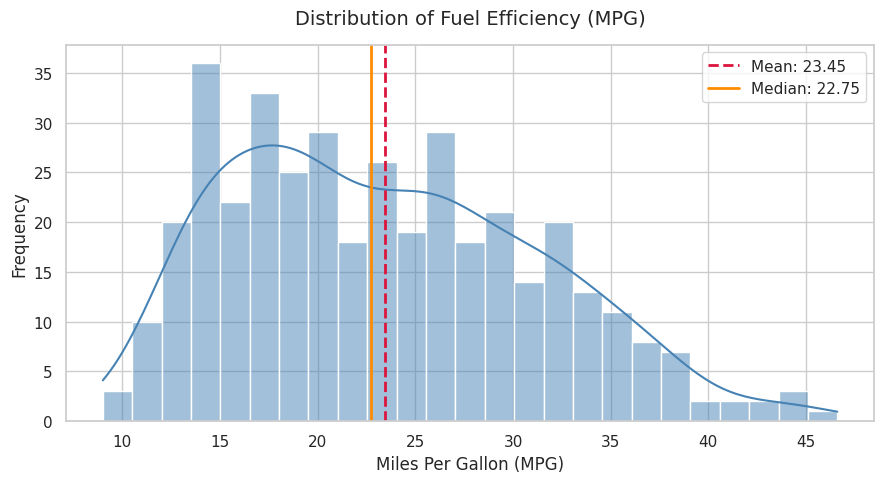

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['mpg'], bins=25, kde=True, color='steelblue', ax=ax)

mpg_mean = df['mpg'].mean()
mpg_median = df['mpg'].median()

ax.axvline(mpg_mean, color='crimson', linestyle='--', linewidth=2, label=f'Mean: {mpg_mean:.2f}')
ax.axvline(mpg_median, color='darkorange', linestyle='-', linewidth=2, label=f'Median: {mpg_median:.2f}')

ax.set_title('Distribution of Fuel Efficiency (MPG)', fontsize=14, pad=15)
ax.set_xlabel('Miles Per Gallon (MPG)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

#### Interpretasi Distribusi:
Distribusi `mpg` tidak simetris melainkan mengalami **skewness positif (Right-Skewed / miring ke kanan)**. Hal ini divalidasi oleh posisi nilai **Mean yang lebih besar daripada Median**. Mayoritas kendaraan berpusat pada tingkat efisiensi rendah hingga menengah, sementara hanya sedikit kendaraan yang memiliki efisiensi sangat tinggi (ekor grafik memanjang ke kanan).

### 7. Origin Comparison Analysis

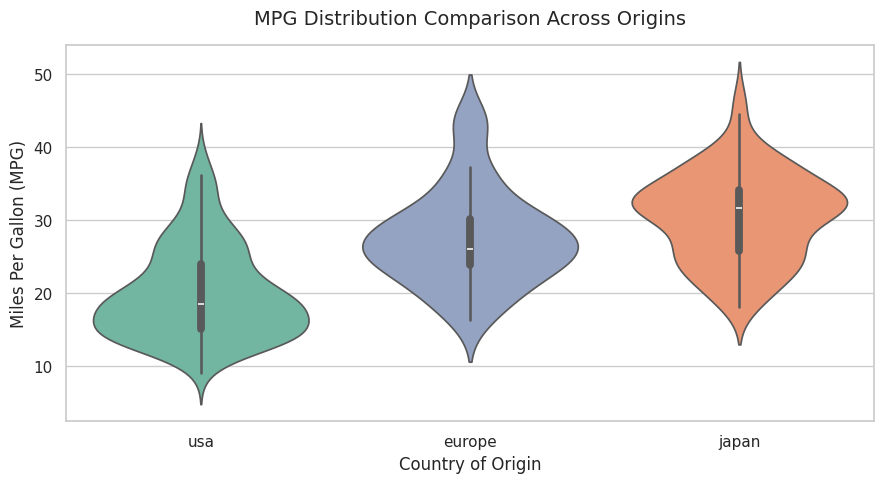

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x='origin', y='mpg', hue='origin', palette='Set2', legend=False, ax=ax, order=['usa', 'europe', 'japan'])

ax.set_title('MPG Distribution Comparison Across Origins', fontsize=14, pad=15)
ax.set_xlabel('Country of Origin', fontsize=12)
ax.set_ylabel('Miles Per Gallon (MPG)', fontsize=12)
plt.tight_layout()
plt.show()

#### Interpretasi Origin:
* **Kendaraan Paling Efisien:** **Japan (Jepang)** memproduksi kendaraan dengan efisiensi bahan bakar tertinggi, diikuti oleh Eropa, dan terakhir USA.
* **Konsistensi:** Kendaraan **USA** memiliki sebaran variasi yang rendah namun menetap di nilai MPG rendah (konsisten boros). Sebaliknya, produk **Jepang** menunjukkan konsistensi efisiensi yang sangat baik dengan kepadatan data (*density*) yang tinggi di rentang nilai MPG atas, mencerminkan fokus manufaktur mereka pada mobil kompak hemat energi.

### 8. Weight vs MPG Relationship

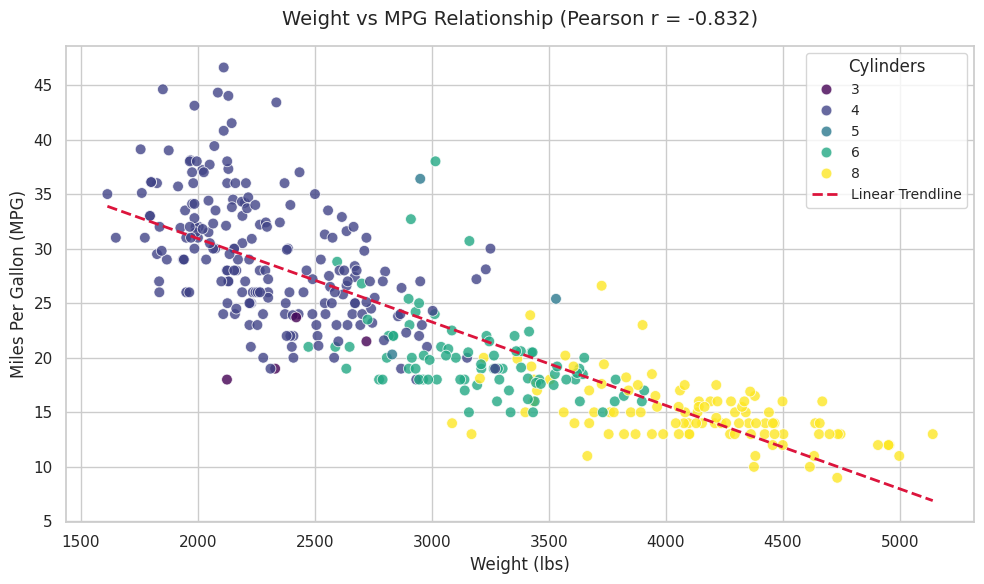

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='viridis', alpha=0.8, s=60, ax=ax)

w_raw = df['weight'].to_numpy()
m_raw = df['mpg'].to_numpy()
slope, intercept = np.polyfit(w_raw, m_raw, 1)

x_line = np.linspace(w_raw.min(), w_raw.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='crimson', linestyle='--', linewidth=2, label='Linear Trendline')

r_val = np.corrcoef(w_raw, m_raw)[0, 1]
ax.set_title(f'Weight vs MPG Relationship (Pearson r = {r_val:.3f})', fontsize=14, pad=15)
ax.set_xlabel('Weight (lbs)', fontsize=12)
ax.set_ylabel('Miles Per Gallon (MPG)', fontsize=12)
ax.legend(title='Cylinders', fontsize=10)
plt.tight_layout()
plt.show()

### 9. Correlation Heatmap & Multicollinearity Pattern

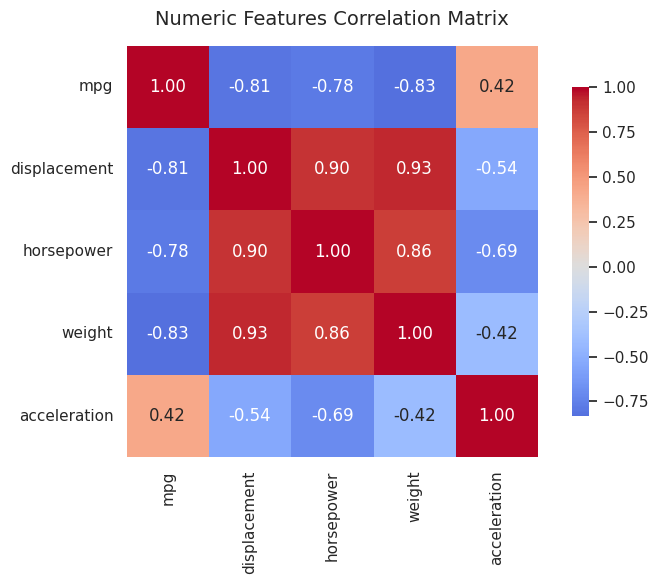

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={"shrink": .8}, ax=ax)

ax.set_title('Numeric Features Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### Pola Multikolinearitas Terdeteksi:
Heatmap memperlihatkan adanya **multikolinearitas parah** pada klaster fitur **`displacement`**, **`horsepower`**, dan **`weight`**. Hubungan linier antar-sesama variabel independen ini berada di atas 0.85 (bahkan korelasi *displacement-weight* menyentuh 0.93). Variabel-variabel tersebut membawa informasi redundant yang berpotensi merusak stabilitas koefisien jika dipaksakan masuk bersamaan ke dalam model regresi linier standar.

## Stage 4: Contextual Interpretation

### 10. Faktor Utama Penentu Efisiensi Bahan Bakar (MPG)
Berdasarkan seluruh rangkaian analisis, **Bobot Kendaraan (`weight`)** merupakan faktor yang paling kuat memprediksi efisiensi bahan bakar kendaraan.

* **Bukti Statistik:** Memiliki koefisien korelasi negatif paling ekstrem sebesar **-0.83**.
* **Analisis Pendukung:** Visualisasi grafik sebaran menunjukkan hukum fisika linear: kendaraan yang lebih berat memerlukan energi mekanikal yang lebih besar untuk bergerak. Selain itu, kendaraan dengan jumlah silinder masif (6 dan 8 silinder) mendominasi klaster bobot terberat, yang berbanding lurus dengan rendahnya nilai MPG kendaraan tersebut.

### 11. Analisis Tren Temporal: Rata-rata MPG per Dekade

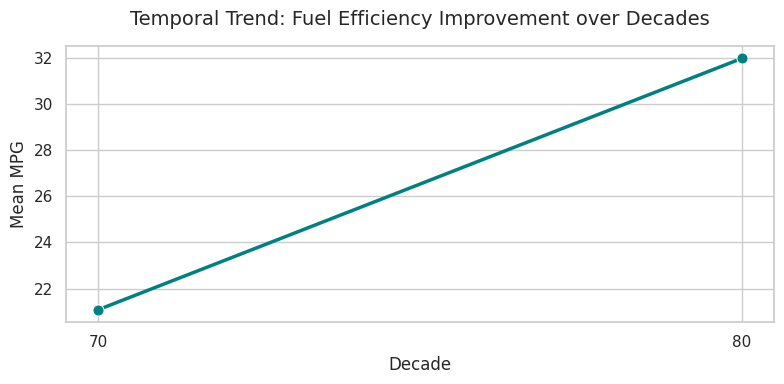

In [ ]:
df['decade'] = (df['model_year'] // 10) * 10
decade_mpg = df.groupby('decade')['mpg'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=decade_mpg, x='decade', y='mpg', marker='o', linewidth=2.5, color='teal', markersize=8, ax=ax)

ax.set_title('Temporal Trend: Fuel Efficiency Improvement over Decades', fontsize=14, pad=15)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Mean MPG', fontsize=12)
ax.set_xticks(decade_mpg['decade'])
plt.tight_layout()
plt.show()

#### Interpretasi Tren Historis:
Peningkatan rata-rata MPG yang signifikan dari era 1970-an menuju 1980-an didorong oleh **Krisis Minyak Global (*1970s Oil Crisis*)**. Lonjakan harga bahan bakar internasional memaksa lahirnya regulasi ketat dari pemerintah (seperti standar CAFE di AS) bagi produsen otomotif. Untuk bertahan di pasar, industri otomotif melakukan transformasi struktural: meninggalkan mesin besar bertenaga boros, mengadopsi material berbahan ringan, dan merancang konfigurasi mesin silinder yang lebih efisien serta ekonomis.

## Bonus 1: Normal Equation from Scratch
Penyelesaian analitis regresi linier tunggal menggunakan persamaan:
$$\hat{\theta} = (X^T X)^{-1} X^T y$$

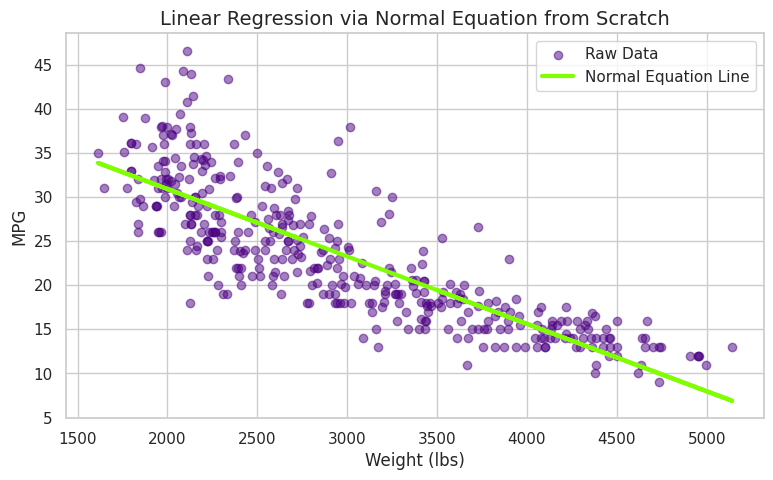

=== Comparison Report ===
Normal Equation Intercept : 46.2165 | Slope: -0.007647
NumPy polyfit() Intercept : 46.2165 | Slope: -0.007647
Calculated Regression RMSE: 4.3216


In [ ]:
X_raw = df['weight'].to_numpy().reshape(-1, 1)
y_raw = df['mpg'].to_numpy()

# 1. Add a bias column
N = X_raw.shape[0]
X_bias = np.hstack([np.ones((N, 1)), X_raw])

# 2. Compute via analytical formulation
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y_raw
intercept_normal, slope_normal = theta[0], theta[1]

# 3. Prediction for plotting
y_pred_normal = X_bias @ theta

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_raw, y_raw, color='indigo', alpha=0.5, label='Raw Data')
ax.plot(X_raw, y_pred_normal, color='chartreuse', linewidth=3, label='Normal Equation Line')
ax.set_title('Linear Regression via Normal Equation from Scratch', fontsize=14)
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('MPG')
ax.legend()
plt.show()

# 4. Compute RMSE
rmse_val = np.sqrt(np.mean((y_pred_normal - y_raw) ** 2))

# 5. Compare with np.polyfit()
slope_poly, intercept_poly = np.polyfit(df['weight'], df['mpg'], 1)

print("=== Comparison Report ===")
print(f"Normal Equation Intercept : {intercept_normal:.4f} | Slope: {slope_normal:.6f}")
print(f"NumPy polyfit() Intercept : {intercept_poly:.4f} | Slope: {slope_poly:.6f}")
print(f"Calculated Regression RMSE: {rmse_val:.4f}")

## Bonus 2: PCA from Scratch
Reduksi dimensi matriks 5 fitur numerik menjadi 2 komponen utama (*Principal Components*).

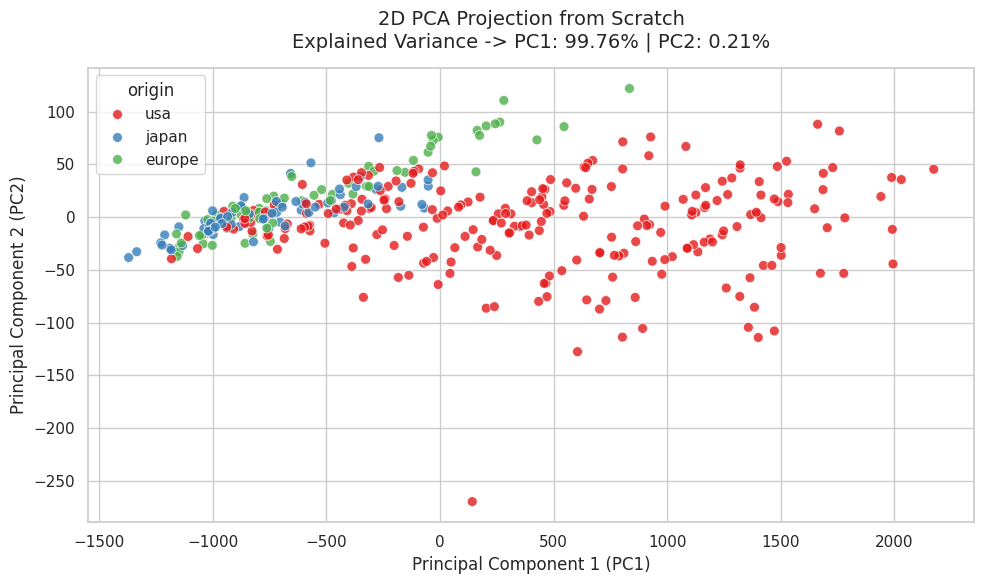

In [ ]:
# 1. Mean-centre all features
X_pca = df[['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']].to_numpy()
X_centered = X_pca - np.mean(X_pca, axis=0)

# 2. Compute the covariance matrix
n_samples = X_centered.shape[0]
covariance_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

# 3. Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Select top 2 eigenvectors
V_2 = eigenvectors[:, :2]

# 5. Project the data to 2D
Z = X_centered @ V_2

# 6. Explained variance ratio
total_variance = np.sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance

pca_df = pd.DataFrame(Z, columns=['PC1', 'PC2'])
pca_df['origin'] = df['origin']

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='origin', palette='Set1', alpha=0.8, s=50, ax=ax)

ax.set_title(f'2D PCA Projection from Scratch\n'
             f'Explained Variance -> PC1: {explained_variance_ratio[0]*100:.2f}% | '
             f'PC2: {explained_variance_ratio[1]*100:.2f}%', fontsize=14, pad=15)
ax.set_xlabel('Principal Component 1 (PC1)', fontsize=12)
ax.set_ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.tight_layout()
plt.show()

## Bonus 3: Reusable EDA Class
Membangun sebuah *framework class analysis* terstruktur berbasis OOP untuk automasi profil dataset.

In [ ]:
import json

class DatasetProfiler:
    def __init__(self, dataframe: pd.DataFrame, target_col: str):
        self.df = dataframe.copy()
        self.target_col = target_col
        self.numeric_df = self.df.select_dtypes(include=[np.number])

    def summary_stats(self) -> pd.DataFrame:
        stats_list = []
        for col in self.numeric_df.columns:
            arr = self.numeric_df[col].dropna().to_numpy()
            q75, q25 = np.percentile(arr, [75, 25])
            iqr = q75 - q25
            outliers = np.sum((arr < (q25 - 1.5 * iqr)) | (arr > (q75 + 1.5 * iqr)))

            stats_list.append({
                'Mean': np.mean(arr),
                'Median': np.median(arr),
                'Std Dev': np.std(arr),
                'IQR': iqr,
                'Outlier Count': outliers
            })
        return pd.DataFrame(stats_list, index=self.numeric_df.columns)

    def correlation_report(self) -> pd.Series:
        correlations = {}
        target_arr = self.df[self.target_col].to_numpy()

        for col in self.numeric_df.columns:
            if col == self.target_col:
                continue
            feat_arr = self.df[col].to_numpy()
            r_matrix = np.corrcoef(feat_arr, target_arr)
            correlations[col] = r_matrix[0, 1]

        return pd.Series(correlations).sort_values(ascending=False)

    def plot_dashboard(self, categorical_col: str = None):
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

        sns.histplot(self.df[self.target_col], kde=True, color='teal', ax=axes[0, 0])
        axes[0, 0].set_title(f'Target Variable Distribution ({self.target_col})', fontsize=12)

        if categorical_col and categorical_col in self.df.columns:
            sns.boxplot(data=self.df, x=categorical_col, y=self.target_col, hue=categorical_col, palette='Pastel1', legend=False, ax=axes[0, 1])
            axes[0, 1].set_title(f'{self.target_col} Distribution by {categorical_col}', fontsize=12)
        else:
            axes[0, 1].text(0.5, 0.5, 'Categorical column\nnot provided', ha='center', va='center', fontsize=14, color='gray')
            axes[0, 1].set_title('Categorical Analysis', fontsize=12)

        corr_matrix = self.numeric_df.corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='bwr', center=0, ax=axes[1, 0])
        axes[1, 0].set_title('Features Correlation Matrix', fontsize=12)

        strongest_feat = self.correlation_report().abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feat, y=self.target_col, color='purple', alpha=0.7, ax=axes[1, 1])
        axes[1, 1].set_title(f'Strongest Predictor Interface: {strongest_feat} vs {self.target_col}', fontsize=12)

        plt.tight_layout()
        plt.show()

    def generate_report(self) -> str:
        corr = self.correlation_report()
        multicol_pairs = list(self.numeric_df.corr().unstack().loc[lambda x: (x.abs() > 0.8) & (x != 1.0)].index.to_flat_index())
        cleaned_pairs = [f"{p[0]} <-> {p[1]}" for p in list(set(tuple(sorted(t)) for t in multicol_pairs))]

        report_dict = {
            "dataset_dimensions": self.df.shape,
            "target_variable": self.target_col,
            "strongest_positive_predictor": corr.idxmax(),
            "strongest_positive_coefficient": float(corr.max()),
            "strongest_negative_predictor": corr.idxmin(),
            "strongest_negative_coefficient": float(corr.min()),
            "potential_multicollinearity_pairs": cleaned_pairs
        }
        return json.dumps(report_dict, indent=4)


[1] Descriptive Statistics:


,Mean,Median,Std Dev,IQR,Outlier Count
mpg,23.445918,22.75,7.795046,12.00,0
cylinders,5.471939,4.00,1.703606,4.00,0
displacement,194.411990,151.00,104.510444,170.75,0
horsepower,104.469388,93.50,38.442033,51.00,10
weight,2977.584184,2803.50,848.318447,1389.50,0
acceleration,15.541327,15.50,2.755343,3.25,11
model_year,75.979592,76.00,3.679035,6.00,0
decade,72.168367,70.00,4.120905,0.00,85



[2] Correlation Report:
model_year      0.580541
decade          0.575757
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
dtype: float64

[3] JSON Executive Summary:
{
    "dataset_dimensions": [
        392,
        10
    ],
    "target_variable": "mpg",
    "strongest_positive_predictor": "model_year",
    "strongest_positive_coefficient": 0.5805409660907855,
    "strongest_negative_predictor": "weight",
    "strongest_negative_coefficient": -0.8322442148315753,
    "potential_multicollinearity_pairs": [
        "displacement <-> mpg",
        "displacement <-> horsepower",
        "cylinders <-> horsepower",
        "displacement <-> weight",
        "mpg <-> weight",
        "horsepower <-> weight",
        "cylinders <-> displacement",
        "cylinders <-> weight"
    ]
}


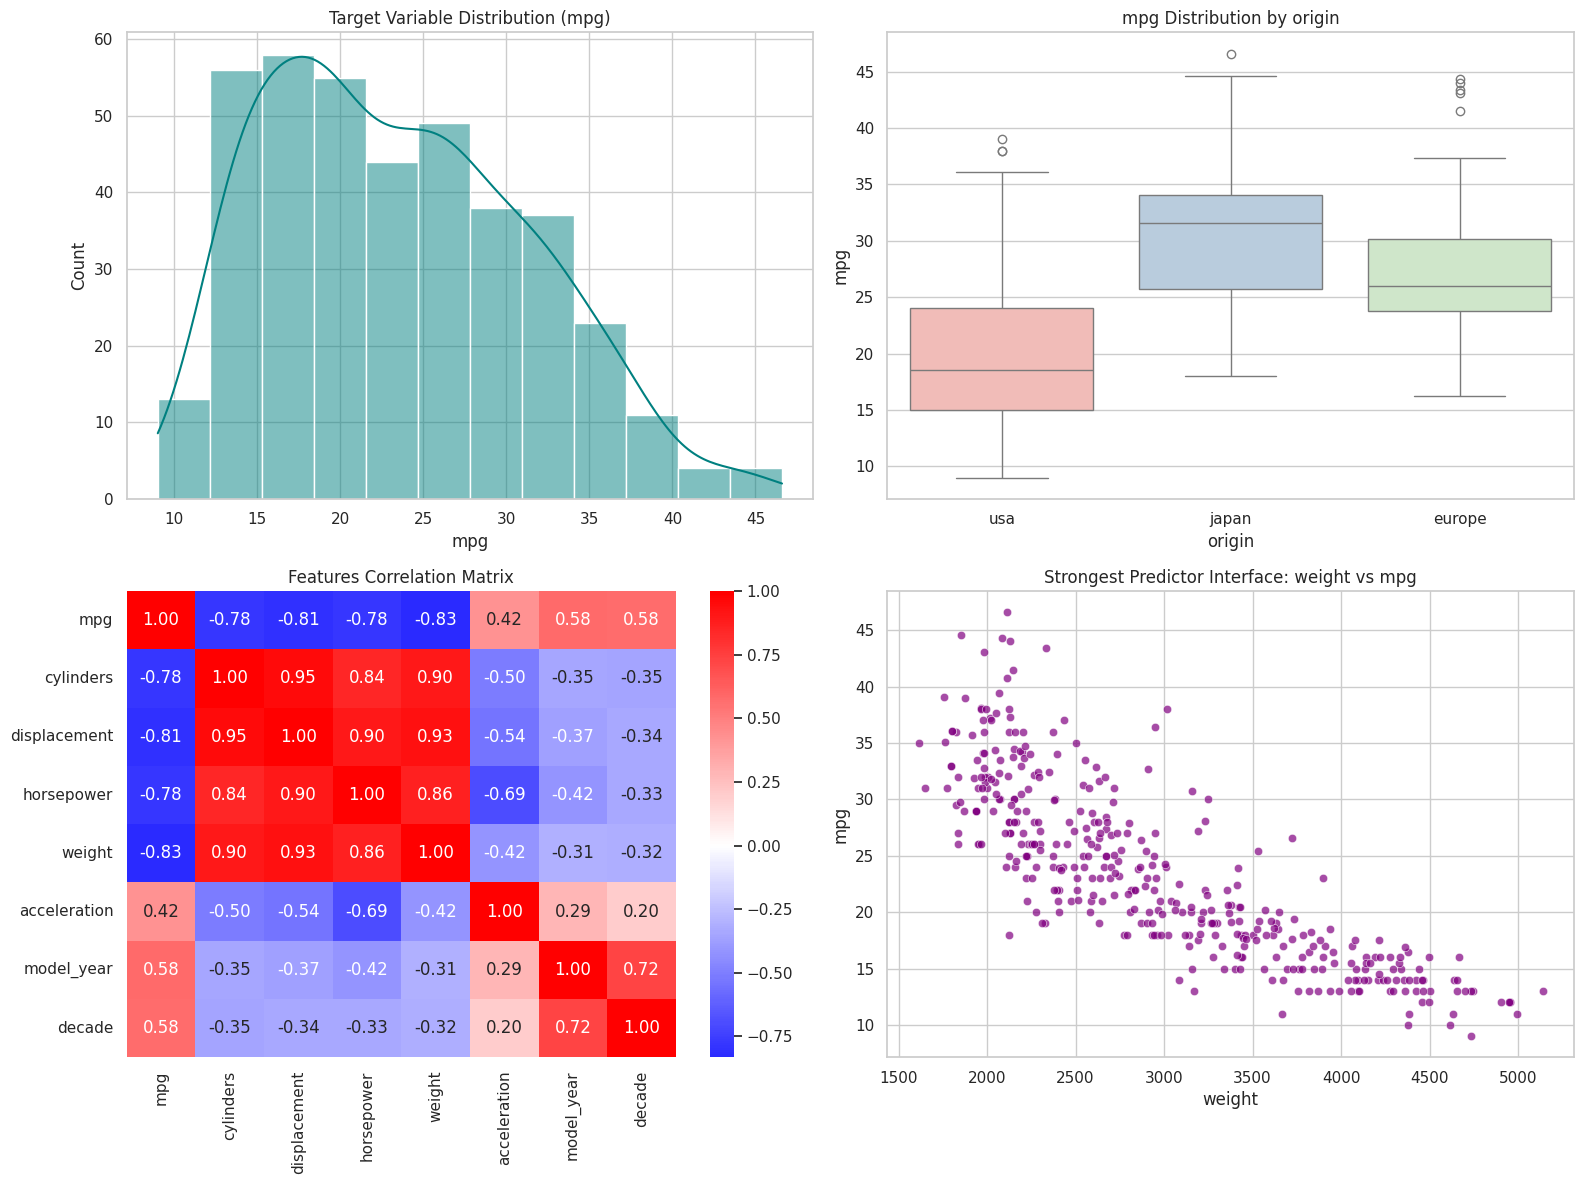

In [ ]:
profiler = DatasetProfiler(df, target_col='mpg')

print("\n[1] Descriptive Statistics:")
display(profiler.summary_stats())

print("\n[2] Correlation Report:")
print(profiler.correlation_report())

print("\n[3] JSON Executive Summary:")
print(profiler.generate_report())

profiler.plot_dashboard(categorical_col='origin')